In [41]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [42]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [43]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

In [44]:
from shapely.geometry import LineString
from shapely.ops import split


gdf = gpd.read_file('200m/200m.shp')
b200 = gdf.to_crs(epsg= 4256)

# Build GeoDataFrame
b200_3 = b200

In [45]:
b200_3

,id,fid,id_pjuridi,Areas,geometry
0,10,sst_mean_nc_min_polys.15,14.0,2,"POLYGON ((-9.31939 38.47282, -9.35137 38.47248..."
1,1,sst_mean_nc_min_polys.1,4.0,1,"POLYGON ((-9.98243 39.10737, -9.98299 39.10987..."
2,6,sst_mean_nc_min_polys.6,17.0,3,"POLYGON ((-7.70448 36.9503, -7.77327 36.9315, ..."


In [46]:
def build_shape_mask(ds, shapefile):
    """
    Build a boolean mask on the native OISST grid.
    Assumes ds.lon is in 0-360 format.
    """

    gdf = shapefile.to_crs("EPSG:4326")

    # ---- convert shapefile lon from -180..180 → 0..360 ----
    gdf["geometry"] = gdf.geometry.translate(xoff=360)
    gdf["geometry"] = gdf.geometry.buffer(0)

    # grid spacing
    dlat = float(abs(ds.lat[1] - ds.lat[0]))
    dlon = float(abs(ds.lon[1] - ds.lon[0]))

    # raster transform (cell-centered grid)
    transform = from_origin(
        ds.lon.min().item() - dlon / 2,
        ds.lat.max().item() + dlat / 2,
        dlon,
        dlat
    )

    mask = geometry_mask(
        gdf.geometry,
        out_shape=(ds.dims["lat"], ds.dims["lon"]),
        transform=transform,
        invert=True
    )

    # flip latitude to match xarray ordering
    mask = mask[::-1, :]

    return xr.DataArray(
        mask,
        coords={"lat": ds.lat, "lon": ds.lon},
        dims=("lat", "lon")
    )


In [47]:
ref_ds = xr.open_dataset("oisst_daily/sst.day.mean.1982.nc")
shape_masks = {'NW': build_shape_mask(ref_ds, b200_3. iloc[[0]]),
               'SW': build_shape_mask(ref_ds, b200_3.iloc[[1]]),
               'S': build_shape_mask(ref_ds, b200_3.iloc[[2]])}

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_94598/8589276.py:27: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_94598/8589276.py:27: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_94598/8589276.py:27: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.



## Get Baseline

Baseline used is 1981-2010

In [48]:
baseline_df = pd.DataFrame()

for year in range(1982, 2012):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])

baseline_df.reset_index(inplace= True)   
del var

Opening 1982
Opening 1983
Opening 1984
Opening 1985
Opening 1986
Opening 1987
Opening 1988
Opening 1989
Opening 1990
Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011


## Years to Analyse

#### Slice datasets' coordinates

## Conversion to ordinal time

In [49]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [50]:
class Year:
    def __init__(self, year, shape_masks):
        self.year = year
        self.shape_masks = shape_masks
        
        self.sliced = {}
        for zone in ['NW', 'SW', 'S']:
            self.sliced[zone] = self.slice(zone)

        self.results = {}
        for zone in ['NW', 'SW', 'S']:
            self.results[zone] = self.detect_MHW(zone)
        
        self.table = self.create_table()


    def slice(self, zone):
        print('Slicing OISST Data')
        oisst = xr.open_dataset(f"oisst_daily/sst.day.mean.{self.year}.nc", 
                        engine="netcdf4", decode_times=True)
    
        oisst_sel = spatial_subset(oisst).where(self.shape_masks[zone])
        oisst_sst = oisst_sel["sst"]
        df = oisst_sst.to_dataframe().reset_index()
        df = df.dropna(subset=['sst'])
        return df
    
    
    def detect_MHW(self, zone, climatology_period=(1982, 2011)):
        print('Detecting MHWs')
        results = []

        for (lat, lon), group_year in self.sliced[zone].groupby(["lat", "lon"]):

            # --- year data ---
            y_sst = group_year["sst"].values
            y_time = group_year["time"].values
            y_time_ord = to_ordinal(y_time)

            # --- baseline for same grid cell ---
            base_group = baseline_df[
                (baseline_df["lat"] == lat) &
                (baseline_df["lon"] == lon)
            ]

            if base_group.empty:
                continue

            base_sst = base_group["sst"].values
            base_time = base_group["time"].values
            base_time_ord = to_ordinal(base_time)

            base_years = pd.to_datetime(base_time).year

            if (base_years.min() > climatology_period[0] or
                base_years.max() < climatology_period[1]):
                continue

            # --- MHW detection ---
            mhw_ev, clim = mhw.detect(
                y_time_ord,
                y_sst,
                climatologyPeriod= list(climatology_period),
                alternateClimatology= [base_time_ord, base_sst]
            )

            results.append({
                "year": pd.to_datetime(y_time[0]).year,
                "lat": lat,
                "lon": lon,
                "n_events": mhw_ev["n_events"],
                "total_duration": (
                    np.sum(mhw_ev["duration"])
                ),
                "max_intensity": (
                    np.max(mhw_ev["intensity_max"])
                    if mhw_ev["n_events"] > 0 else np.nan
                ),
                "mean_intensity":
                    float(np.mean(mhw_ev["intensity_mean"])),
                'cummulative_intensity': 
                    np.sum(mhw_ev['intensity_cumulative']),
            })

        return pd.DataFrame(results)
    

    def create_table(self):
        print('Creating Table')
        nw = self.results['NW'].drop(columns=['year', 'lat', 'lon']).agg(['min', 'max', 'mean', 'std'])
        sw = self.results['SW'].drop(columns=['year', 'lat', 'lon']).agg(['min', 'max', 'mean', 'std'])
        s = self.results['S'].drop(columns=['year', 'lat', 'lon']).agg(['min', 'max', 'mean', 'std'])

        final_df = pd.concat([nw, sw, s], keys=['NW', 'SW', 'S']).T
        return final_df

In [51]:
yearDict = {}
for i in range(1982, 2026):
    print(f'Treating {i}')
    year = Year(i, shape_masks)
    yearDict[i] = year

np.save('yearDict200m.npy', yearDict)


Treating 1982
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1983
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1984
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1985
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1986
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1987
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1988
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
Detecting MHWs
Detecting MHWs
Creating Table
Treating 1989
Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MH

In [52]:
yearDictS = np.load('yearDict200m.npy', allow_pickle=True).item()

In [38]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
meanNEventsNW = [[i, yearDict[i].table.loc['n_events', ('NW', 'mean')]] for i in range(1982,2026)]
meanNEventsSW = [[i, yearDict[i].table.loc['n_events', ('SW', 'mean')]] for i in range(1982,2026)]
meanNEventsS = [[i, yearDict[i].table.loc['n_events', ('S', 'mean')]] for i in range(1982,2026)]

dfNW = pd.DataFrame(
    meanNEventsNW,
    columns=['Year', 'Mean_N_Events']
)

dfSW = pd.DataFrame(
    meanNEventsSW,
    columns=['Year', 'Mean_N_Events']
)
dfS = pd.DataFrame(
    meanNEventsS,
    columns=['Year', 'Mean_N_Events']
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dfNW['Year'],
        y=dfNW['Mean_N_Events'],
        mode='lines+markers',
        name='NW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfSW['Year'],
        y=dfSW['Mean_N_Events'],
        mode='lines+markers',
        name='SW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfS['Year'],
        y=dfS['Mean_N_Events'],
        mode='lines+markers',
        name='S'
    )
)

fig.update_layout(
    title="Mean Number of Events",
    xaxis_title="Year",
    yaxis_title="Mean events"
)

fig.show()

In [24]:
meanNEventsNW = [[i, yearDict[i].table.loc['cummulative_intensity', ('NW', 'mean')]] for i in range(1996,2026)]
meanNEventsSW = [[i, yearDict[i].table.loc['cummulative_intensity', ('SW', 'mean')]] for i in range(1996,2026)]
meanNEventsS = [[i, yearDict[i].table.loc['cummulative_intensity', ('S', 'mean')]] for i in range(1996,2026)]

dfNW = pd.DataFrame(
    meanNEventsNW,
    columns=['Year', 'cummulative_intensity']
)

dfSW = pd.DataFrame(
    meanNEventsSW,
    columns=['Year', 'cummulative_intensity']
)
dfS = pd.DataFrame(
    meanNEventsS,
    columns=['Year', 'cummulative_intensity']
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dfNW['Year'],
        y=dfNW['cummulative_intensity'],
        mode='lines+markers',
        name='NW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfSW['Year'],
        y=dfSW['cummulative_intensity'],
        mode='lines+markers',
        name='SW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfS['Year'],
        y=dfS['cummulative_intensity'],
        mode='lines+markers',
        name='S'
    )
)

fig.update_layout(
    title="Mean Commulative Intensity",
    xaxis_title="Year",
    yaxis_title="Commulative Intensity"
)

fig.show()

In [25]:
meanNEventsNW = [[i, yearDict[i].table.loc['total_duration', ('NW', 'mean')]] for i in range(1996,2026)]
meanNEventsSW = [[i, yearDict[i].table.loc['total_duration', ('SW', 'mean')]] for i in range(1996,2026)]
meanNEventsS = [[i, yearDict[i].table.loc['total_duration', ('S', 'mean')]] for i in range(1996,2026)]

dfNW = pd.DataFrame(
    meanNEventsNW,
    columns=['Year', 'total_duration']
)

dfSW = pd.DataFrame(
    meanNEventsSW,
    columns=['Year', 'total_duration']
)
dfS = pd.DataFrame(
    meanNEventsS,
    columns=['Year', 'total_duration']
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dfNW['Year'],
        y=dfNW['total_duration'],
        mode='lines+markers',
        name='NW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfSW['Year'],
        y=dfSW['total_duration'],
        mode='lines+markers',
        name='SW'
    )
)
fig.add_trace(
    go.Scatter(
        x=dfS['Year'],
        y=dfS['total_duration'],
        mode='lines+markers',
        name='S'
    )
)


fig.update_layout(
    title="Mean Total Duration",
    xaxis_title="Year",
    yaxis_title="Total Duration"
)
fig.show()

## Graphs

#### By number of events

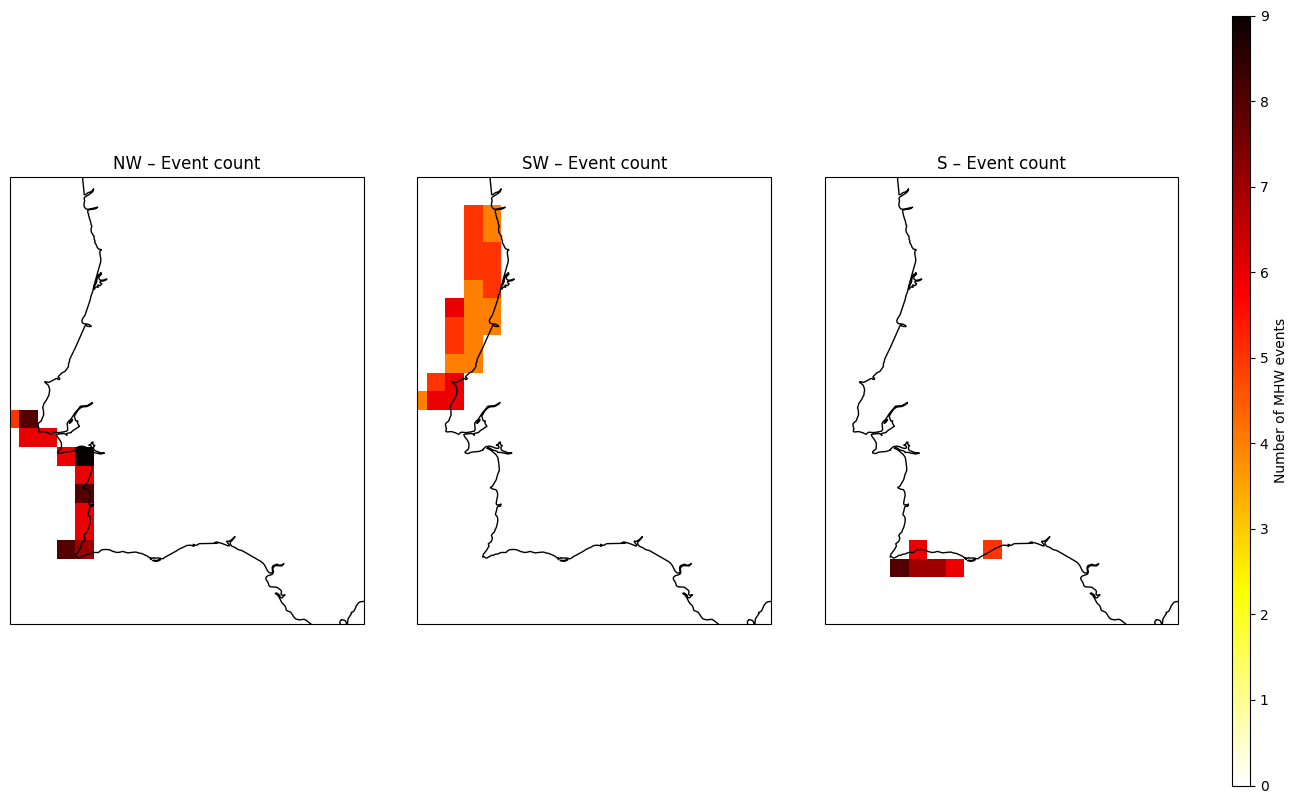

In [ ]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_plot = spatial_subset(
    xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", decode_times=True)
)

lon = ds_plot.lon.values
lat = ds_plot.lat.values
lon2d, lat2d = np.meshgrid(lon, lat)



fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 4, width_ratios=[1,1,1,0.05])

regions = ["NW","SW","S"]
vmax = max(mhw_2023[r]["n_events"].max() for r in regions)

for i, r in enumerate(regions):

    df = mhw_2023[r]

    grid = (
        df.pivot(index="lat", columns="lon", values="n_events")
          .reindex(index=lat, columns=lon)
          .fillna(0)
          .values
    )

    ax = fig.add_subplot(gs[0,i], projection=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        lon2d, lat2d, grid,
        cmap="hot_r",
        shading="nearest",
        vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()])
    ax.add_feature(cfeature.COASTLINE)
    ax.set_title(f"{r} – Event count")

cax = fig.add_subplot(gs[0,-1])
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of MHW events")

plt.show()


#### By total duration

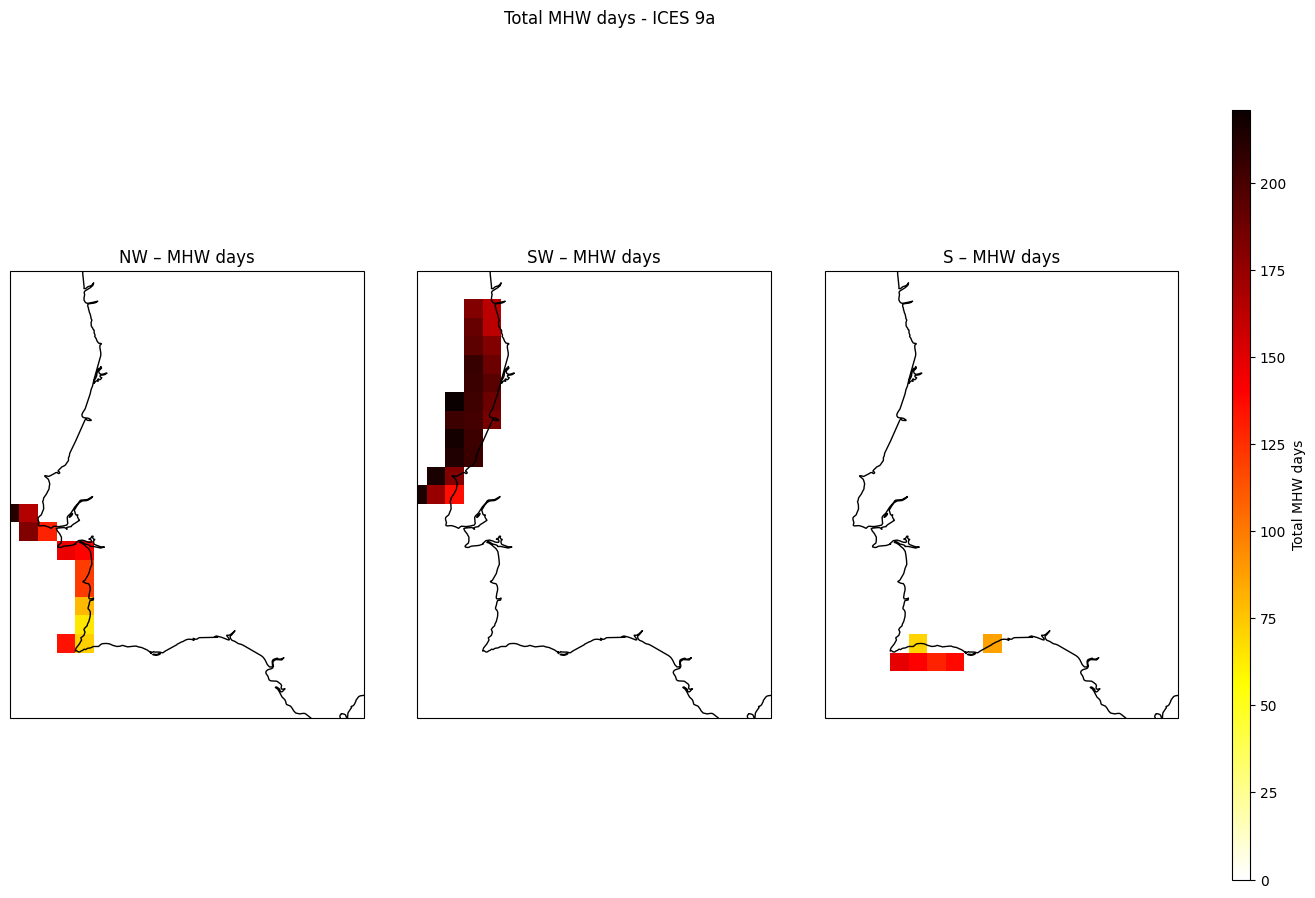

In [ ]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_plot = spatial_subset(
    xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", decode_times=True)
)

lon = ds_plot.lon.values
lat = ds_plot.lat.values
lon2d, lat2d = np.meshgrid(lon, lat)



fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 4, width_ratios=[1,1,1,0.05])

regions = ["NW","SW","S"]
vmax = max(mhw_2023[r]["total_duration"].max() for r in regions)

for i, r in enumerate(regions):

    df = mhw_2023[r]

    grid = (
        df.pivot(index="lat", columns="lon", values="total_duration")
          .reindex(index=lat, columns=lon)
          .fillna(0)
          .values
    )

    ax = fig.add_subplot(gs[0,i], projection=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        lon2d, lat2d, grid,
        cmap="hot_r",
        shading="nearest",
        vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()])
    ax.add_feature(cfeature.COASTLINE)
    ax.set_title(f"{r} – MHW days")

cax = fig.add_subplot(gs[0,-1])
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Total MHW days")

fig.suptitle('Total MHW days - ICES 9a')
plt.show()
